# Prediksi Jumlah Produksi Tin Stabilizer Bulan Berikutnya Menggunakan XGBoost Regression

**Produk:** MT-620 (Tin Stabilizer) | **Dataset:** Data_Chemical_2026.04-16-MT620.xlsx

Notebook ini mengikuti alur penelitian pada proposal (20 tahapan) dan dilengkapi referensi ilmiah pada
tiap tahap. Beberapa tahapan **ditambahkan/disesuaikan** agar metodologinya benar & jujur secara ilmiah
(ditandai **[TAMBAHAN]** atau **[PENYESUAIAN]**).

> **Catatan kejujuran ilmiah (wajib dibaca):**
> 1. Dataset tidak memiliki kolom "jumlah produksi" eksplisit -> **target = jumlah batch per bulan**
>    (proksi volume produksi).
> 2. Rentang data nyata hanya **~12 bulan (Mei 2025 - Apr 2026)**, sehingga skema "Training 2022-2025 /
>    Testing 2026" pada proposal **tidak dapat dipakai**; diganti pembagian berurutan waktu + TimeSeriesSplit.
> 3. Bulan pertama & terakhir adalah **bulan parsial** (data tak penuh sebulan).
> 4. Karena titik bulanan sangat sedikit, hasil XGBoost **wajib dibandingkan dengan baseline** dan dibaca
>    hati-hati (Bagian 16 & 21).

## Metode Penelitian

![Metode Penelitian](metode_penelitian.png)

*(Letakkan file `metode_penelitian.png` di folder yang sama agar gambar tampil.)*

## 1. Pendahuluan

**Tujuan.** Membangun model **XGBoost Regression** untuk memprediksi jumlah produksi Tin Stabilizer pada
bulan berikutnya berdasarkan data historis produksi & parameter Quality Control (QC).

**Pendekatan.** *Supervised learning* berbasis deret waktu dengan fitur historis.

**Referensi.** Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* ACM SIGKDD. https://doi.org/10.1145/2939672.2939785

## 2. Import Library

**Tujuan.** Mengimpor seluruh pustaka Python yang diperlukan.

**Referensi.** McKinney (2010) *pandas*; Harris et al. (2020) *NumPy*, Nature; Pedregosa et al. (2011) *Scikit-learn*, JMLR.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import shap; HAS_SHAP=True
except Exception:
    HAS_SHAP=False
try:
    import joblib; HAS_JOBLIB=True
except Exception:
    HAS_JOBLIB=False

RANDOM_STATE=42
sns.set(style='whitegrid')
print('Library siap. SHAP:', HAS_SHAP, '| joblib:', HAS_JOBLIB)

Library siap. SHAP: True | joblib: True


## 3. Membaca Dataset

**Tujuan.** Membaca dataset ke DataFrame.

**Referensi.** Kuhn, M., & Johnson, K. (2013). *Applied Predictive Modeling.* Springer.

In [2]:
file_path = r"Data_Chemical_2026.04-16-MT620.xlsx"  
df = pd.read_excel(file_path)
print('Ukuran dataset mentah:', df.shape)
df.head()

Ukuran dataset mentah: (1851, 19)


,No,Nama Chemical,Nama,Tanggal,Jam Masuk,Batch,Transmission,APE,Tin,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT
0,1,Tinstab,MT-620,2025-05-07,2025-05-15 13:02:21,TG2024L28,99.275,Clear,19.129,1.50867,1.1723,0.203,12.081,3.48,23.750,7.84,0.0001,47.20,10.0
1,2,Tinstab,MT-620,2025-05-07,2025-05-15 13:02:43,TG2025A07,99.229,Clear,19.173,1.50882,1.1738,0.254,11.926,3.48,22.980,7.90,0.0005,45.07,10.0
2,3,Tinstab,MT-620,2025-05-07,2025-05-15 13:02:44,TG2025B07-1,99.072,Clear,18.934,1.50981,1.1650,0.970,11.940,1.97,21.939,9.03,0.3969,51.80,9.0
3,4,Tinstab,MT-620,2025-05-09,2025-05-19 17:44:11,TG02025E05,99.216,Clear,19.070,1.50849,1.1694,0.253,12.099,3.49,23.750,7.85,0.0001,49.60,10.0
4,5,Tinstab,MT-620,2025-05-09,2025-05-19 16:56:22,TG02025E06,99.308,Clear,19.176,1.50882,1.1724,0.250,12.176,3.49,23.210,7.82,0.0001,47.20,10.0


## 4. Exploratory Data Analysis (EDA)

**Tujuan.** Memahami karakteristik dataset: ukuran, tipe data, statistik deskriptif, distribusi, korelasi.

**Referensi.** Tukey, J. W. (1977). *Exploratory Data Analysis.* Addison-Wesley.

In [3]:
print('Dimensi   :', df.shape)
print('\nKolom     :', list(df.columns))
print('\nTipe data :'); print(df.dtypes)
df.describe(include='all').T

Dimensi   : (1851, 19)

Kolom     : ['No', 'Nama Chemical', 'Nama', 'Tanggal', 'Jam Masuk', 'Batch', 'Transmission', 'APE', 'Tin', 'RI', 'SG', 'Acid', 'Sulfur', 'Water', 'Mono', 'Yellow', 'EH', 'Visco', 'PT']

Tipe data :
No                 int64
Nama Chemical     object
Nama              object
Tanggal           object
Jam Masuk         object
Batch             object
Transmission     float64
APE               object
Tin              float64
RI               float64
SG               float64
Acid             float64
Sulfur           float64
Water            float64
Mono             float64
Yellow           float64
EH               float64
Visco            float64
PT               float64
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,1851.0,NaN,NaN,NaN,925.99946,534.481057,1.0,463.5,926.0,1388.5,1850.0
Nama Chemical,1851,1,Tinstab,1851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nama,1851,1,MT-620,1851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tanggal,1851,259,2025-12-10,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Jam Masuk,1851,1850,2026-04-12 19:45:06,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Batch,1851,1011,TG2025F02,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,1844.0,NaN,NaN,NaN,99.004445,0.430314,97.412,98.682,99.1135,99.284,99.935
APE,1850,1,Clear,1850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tin,1850.0,NaN,NaN,NaN,19.066585,0.168473,18.807,18.9485,19.043,19.122,19.925
RI,1850.0,NaN,NaN,NaN,1.510049,0.003464,1.50107,1.50823,1.50901,1.509978,1.52331


## 5. Pemeriksaan Missing Value

**Tujuan.** Mengetahui adanya data kosong.

**Referensi.** Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3rd ed.). Wiley.

In [4]:
miss = df.isna().sum()
print(miss[miss>0] if (miss>0).any() else 'Tidak ada missing value.')

Transmission    7
APE             1
Tin             1
RI              1
SG              1
Acid            1
Sulfur          1
Water           1
Mono            1
Yellow          1
EH              1
Visco           1
PT              1
dtype: int64


## 6. Pemeriksaan & Penanganan Data Duplikat

**Tujuan.** Mengidentifikasi & menghapus baris duplikat.

**Referensi.** Han, J., Kamber, M., & Pei, J. (2011). *Data Mining: Concepts and Techniques* (3rd ed.). Morgan Kaufmann.

In [5]:
print('Jumlah baris duplikat:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Ukuran setelah hapus duplikat:', df.shape)

Jumlah baris duplikat: 0
Ukuran setelah hapus duplikat: (1851, 19)


## 6A. Agregasi Bulanan & Definisi Target  **[TAMBAHAN]**

**Tujuan.** Karena dataset berisi hasil QC **per batch** sedangkan target adalah **jumlah produksi per
bulan**, data diagregasi ke level bulanan.

- **Target (y):** `Jumlah_Produksi` = jumlah batch pada bulan tersebut.
- **Fitur QC (X):** rata-rata tiap parameter lab per bulan.

**Referensi.** Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.

In [6]:
qc = ['Transmission','Tin','RI','SG','Acid','Sulfur','Water','Mono','Yellow','EH','Visco','PT']
df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
df = df.dropna(subset=['Tanggal']).copy()
for c in qc: df[c] = pd.to_numeric(df[c], errors='coerce')
df['bulan'] = df['Tanggal'].dt.to_period('M')

prod = df.groupby('bulan').size().rename('Jumlah_Produksi')
qc_month = df.groupby('bulan')[qc].mean()
monthly = pd.concat([prod, qc_month], axis=1).sort_index()
print('Jumlah bulan:', len(monthly), '| rentang:', monthly.index.min(), '-', monthly.index.max())
print('CATATAN: bulan pertama & terakhir kemungkinan PARSIAL.')
monthly

Jumlah bulan: 12 | rentang: 2025-05 - 2026-04
CATATAN: bulan pertama & terakhir kemungkinan PARSIAL.


,Jumlah_Produksi,Transmission,Tin,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT
bulan,,,,,,,,,,,,,
2025-05,81,98.996617,19.075515,1.509003,1.170963,1.124728,11.994679,2.404691,23.804000,7.990494,0.247733,60.577160,14.493827
2025-06,140,99.080550,19.101326,1.509380,1.169804,0.907911,11.982293,2.606143,23.523721,7.993429,0.193516,58.151643,13.221429
2025-07,193,99.015596,19.080227,1.511009,1.169557,0.987083,12.009668,2.383264,23.659430,8.061140,0.231273,58.321140,14.134715
2025-08,186,99.038360,19.124581,1.511346,1.171562,0.925968,12.002753,2.408817,23.390167,8.179914,0.205678,57.918011,13.526882
2025-09,166,98.993187,19.068669,1.510245,1.170877,1.143699,11.928373,2.378133,23.682066,8.088253,0.239543,56.841084,14.975904
2025-10,193,98.990667,19.054735,1.509526,1.170752,1.174601,11.939829,2.285440,23.658109,7.897461,0.256684,57.186580,14.041451
2025-11,145,98.993146,19.094320,1.509739,1.170752,1.117607,11.900745,2.330759,23.730814,7.908552,0.228282,57.730069,15.137931
2025-12,230,99.012771,19.044789,1.509603,1.169963,1.134530,11.912787,2.259783,23.346600,7.880478,0.249323,57.324348,14.565217
2026-01,116,98.940888,19.031233,1.509586,1.170247,1.240929,11.903414,2.361466,23.639862,7.838190,0.241147,59.040000,13.732759


## 7. Analisis Statistik Deskriptif

**Tujuan.** Memahami penyebaran data (mean, median, min, max, std).

**Referensi.** James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.

In [7]:
monthly.describe().T[['mean','50%','min','max','std']].rename(columns={'50%':'median'})

,mean,median,min,max,std
Jumlah_Produksi,154.250000,157.000000,76.000000,230.000000,46.401656
Transmission,99.002214,98.994902,98.940888,99.080550,0.034657
Tin,19.064095,19.063895,19.012721,19.124581,0.033514
RI,1.509987,1.509803,1.509003,1.511346,0.000678
SG,1.170454,1.170499,1.169557,1.171562,0.000601
Acid,1.087315,1.129629,0.907911,1.240929,0.109968
Sulfur,11.961823,11.976619,11.900745,12.009668,0.041973
Water,2.372254,2.369799,2.259783,2.606143,0.098058
Mono,23.557495,23.594032,23.292746,23.804000,0.164577
Yellow,7.970431,7.961767,7.813559,8.179914,0.111113


## 8. Visualisasi Distribusi Data

**Tujuan.** Mengetahui distribusi target & parameter (deret waktu, histogram, boxplot).

**Referensi.** James et al. (2021), *ISLR* (2nd ed.). Springer.

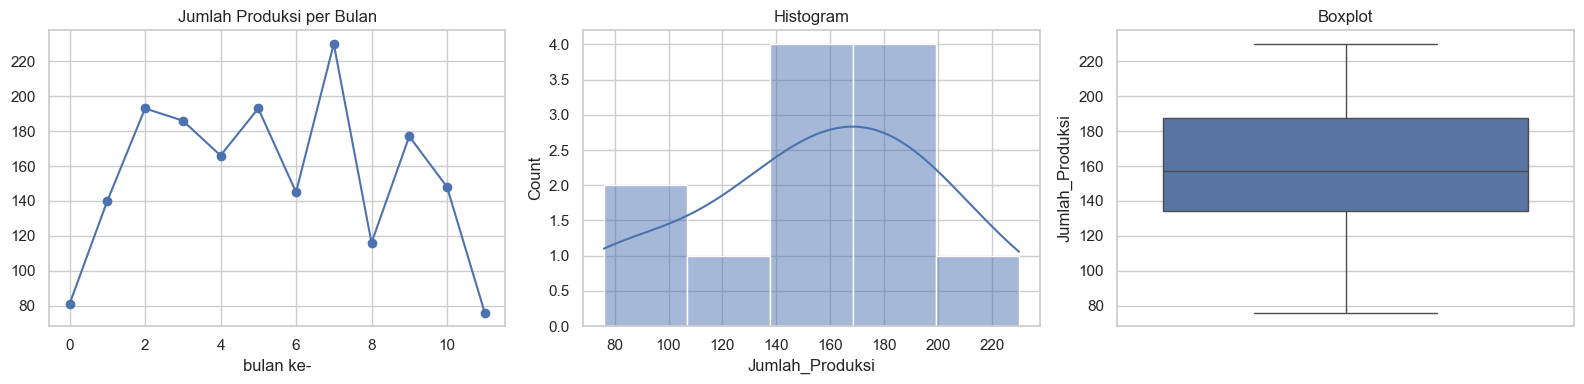

In [8]:
fig, ax = plt.subplots(1,3, figsize=(16,4))
ax[0].plot(range(len(monthly)), monthly['Jumlah_Produksi'], 'o-')
ax[0].set_title('Jumlah Produksi per Bulan'); ax[0].set_xlabel('bulan ke-')
sns.histplot(monthly['Jumlah_Produksi'], kde=True, ax=ax[1]); ax[1].set_title('Histogram')
sns.boxplot(y=monthly['Jumlah_Produksi'], ax=ax[2]); ax[2].set_title('Boxplot')
plt.tight_layout(); plt.show()

## 9. Analisis Korelasi

**Tujuan.** Melihat hubungan linear antar variabel (parameter QC vs jumlah produksi).

**Referensi.** Benesty, J., Chen, J., Huang, Y., & Cohen, I. (2009). *Pearson Correlation Coefficient.* Springer.

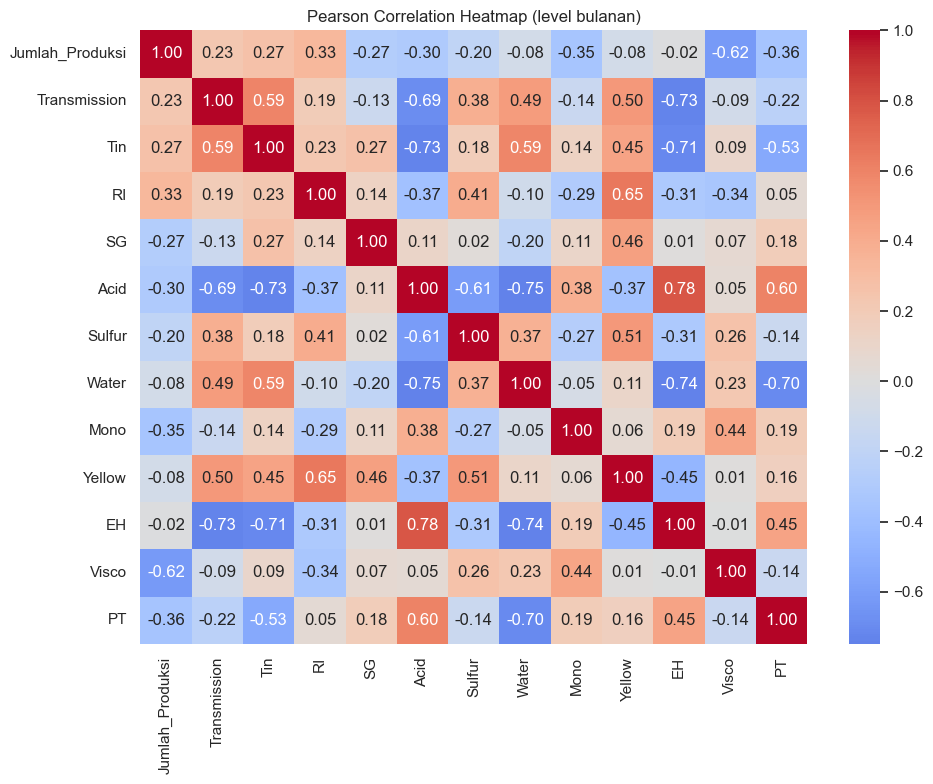

Korelasi tiap fitur terhadap Jumlah_Produksi:
RI              0.332894
Tin             0.266288
Transmission    0.232691
EH             -0.016526
Yellow         -0.082058
Water          -0.083590
Sulfur         -0.196819
SG             -0.272600
Acid           -0.297525
Mono           -0.345924
PT             -0.358924
Visco          -0.617498
Name: Jumlah_Produksi, dtype: float64


In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(monthly.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pearson Correlation Heatmap (level bulanan)'); plt.tight_layout(); plt.show()
print('Korelasi tiap fitur terhadap Jumlah_Produksi:')
print(monthly.corr(numeric_only=True)['Jumlah_Produksi'].drop('Jumlah_Produksi').sort_values(ascending=False))

## 9B. Uji Stasioneritas: ADF & KPSS  **[TAMBAHAN]**

**Tujuan.** Memeriksa apakah deret `Jumlah_Produksi` stasioner (syarat penting pemodelan deret waktu). Uji **ADF** (H0: ada unit root / tidak stasioner) dan **KPSS** (H0: stasioner) saling melengkapi.

**Referensi.** Dickey, D. A., & Fuller, W. A. (1979). *Distribution of the estimators for autoregressive time series with a unit root.* Journal of the American Statistical Association, 74(366), 427-431. Kwiatkowski, D., Phillips, P. C. B., Schmidt, P., & Shin, Y. (1992). *Testing the null hypothesis of stationarity against the alternative of a unit root.* Journal of Econometrics, 54(1-3), 159-178.

In [10]:
ser = monthly['Jumlah_Produksi'].astype(float)
try:
    from statsmodels.tsa.stattools import adfuller, kpss
    adf = adfuller(ser, autolag='AIC')
    print(f'ADF  statistic = {adf[0]:.3f} | p-value = {adf[1]:.3f}')
    print('  -> ' + ('STASIONER (tolak H0)' if adf[1]<0.05 else 'TIDAK stasioner (gagal tolak H0)'))
    try:
        kp = kpss(ser, regression='c', nlags='auto')
        print(f'KPSS statistic = {kp[0]:.3f} | p-value = {kp[1]:.3f}')
        print('  -> ' + ('TIDAK stasioner (tolak H0)' if kp[1]<0.05 else 'STASIONER (gagal tolak H0)'))
    except Exception as e:
        print('KPSS gagal:', e)
except ModuleNotFoundError:
    print('statsmodels belum terpasang -> jalankan: pip install statsmodels')
    print('Rata-rata:', round(ser.mean(),2), '| Std:', round(ser.std(),2),
          '| Std selisih(diff):', round(ser.diff().std(),2))
print('\nCATATAN: dengan ~12 titik bulanan, uji stasioneritas berdaya rendah (low power).')

ADF  statistic = -0.490 | p-value = 0.894
  -> TIDAK stasioner (gagal tolak H0)
KPSS statistic = 0.157 | p-value = 0.100
  -> STASIONER (gagal tolak H0)

CATATAN: dengan ~12 titik bulanan, uji stasioneritas berdaya rendah (low power).


C:\Users\aldee\AppData\Local\Temp\ipykernel_65840\3043101014.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(ser, regression='c', nlags='auto')


## 9C. Analisis Autokorelasi (ACF & PACF)  **[TAMBAHAN]**

**Tujuan.** Menentukan jumlah *lag* yang layak dijadikan fitur. **ACF** mengukur korelasi deret dengan dirinya pada selang waktu tertentu; **PACF** mengukur korelasi parsial. Ini menjadi dasar ilmiah pemilihan `lag1..lag3`.

**Referensi.** Box, G. E. P., & Jenkins, G. M. (1970). *Time Series Analysis: Forecasting and Control.* Holden-Day. Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.

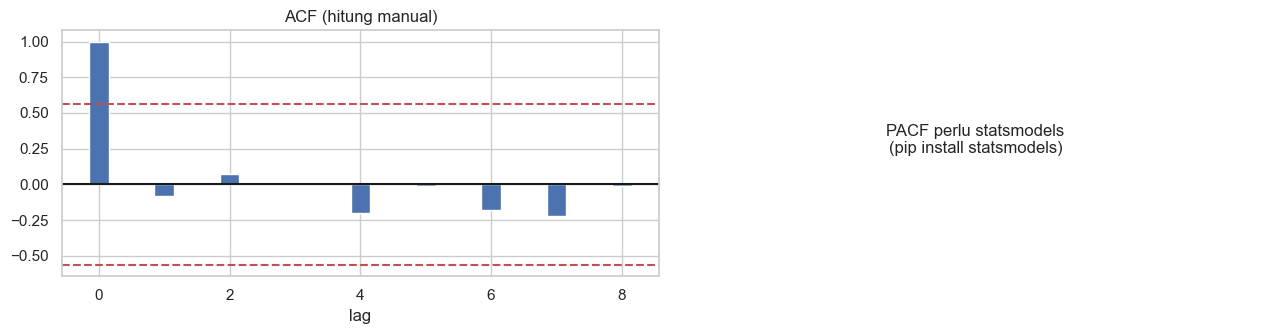

Garis merah = ambang signifikansi 95%. Lag di luar garis -> layak dijadikan fitur.


In [11]:
import numpy as np, matplotlib.pyplot as plt
x = monthly['Jumlah_Produksi'].astype(float).values
xc = x - x.mean(); n = len(x)
maxlag = min(8, n-2)
acf = [1.0] + [float(np.sum(xc[k:]*xc[:-k])/np.sum(xc*xc)) for k in range(1,maxlag+1)]
conf = 1.96/np.sqrt(n)
fig, ax = plt.subplots(1,2, figsize=(13,3.5))
ax[0].bar(range(len(acf)), acf, width=0.3); ax[0].axhline(0,color='k')
ax[0].axhline(conf,color='r',ls='--'); ax[0].axhline(-conf,color='r',ls='--')
ax[0].set_title('ACF (hitung manual)'); ax[0].set_xlabel('lag')
try:
    from statsmodels.graphics.tsaplots import plot_pacf
    plot_pacf(monthly['Jumlah_Produksi'].astype(float), lags=maxlag, ax=ax[1], method='ywm')
    ax[1].set_title('PACF')
except Exception:
    ax[1].text(0.5,0.5,'PACF perlu statsmodels\n(pip install statsmodels)',ha='center'); ax[1].set_axis_off()
plt.tight_layout(); plt.show()
print('Garis merah = ambang signifikansi 95%. Lag di luar garis -> layak dijadikan fitur.')

## 10. Deteksi Outlier (IQR)

**Tujuan.** Mendeteksi nilai ekstrem yang dapat mempengaruhi pelatihan.

**Referensi.** Aggarwal, C. C. (2017). *Outlier Analysis* (2nd ed.). Springer.

In [12]:
def deteksi_outlier_iqr(s):
    q1,q3 = s.quantile(0.25), s.quantile(0.75); iqr=q3-q1
    lo,hi = q1-1.5*iqr, q3+1.5*iqr
    return s[(s<lo)|(s>hi)]
out = deteksi_outlier_iqr(monthly['Jumlah_Produksi'])
print(out if len(out) else 'Tidak ada outlier pada jumlah produksi.')
print('Catatan: bulan parsial bisa tampak sebagai outlier rendah; pertimbangkan dikecualikan.')

Tidak ada outlier pada jumlah produksi.
Catatan: bulan parsial bisa tampak sebagai outlier rendah; pertimbangkan dikecualikan.


## 11. Feature Engineering

**Tujuan.** Membentuk fitur historis: lag 1-3, rolling mean, month, year, rata-rata parameter QC.

**Referensi.** Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.

In [13]:
feat = pd.DataFrame(index=monthly.index)
feat['lag1'] = monthly['Jumlah_Produksi'].shift(1)
feat['lag2'] = monthly['Jumlah_Produksi'].shift(2)
feat['lag3'] = monthly['Jumlah_Produksi'].shift(3)
feat['rolling_mean_3'] = monthly['Jumlah_Produksi'].shift(1).rolling(3).mean()
feat['month'] = monthly.index.month
feat['year']  = monthly.index.year
for c in qc: feat[f'qc_{c}'] = monthly[c]
feat['target'] = monthly['Jumlah_Produksi']

data = feat.dropna().reset_index(drop=True)
feature_cols = [c for c in data.columns if c!='target']
print('Baris siap latih:', len(data), '| jumlah fitur:', len(feature_cols))
data

Baris siap latih: 9 | jumlah fitur: 18


,lag1,lag2,lag3,rolling_mean_3,month,year,qc_Transmission,qc_Tin,qc_RI,qc_SG,qc_Acid,qc_Sulfur,qc_Water,qc_Mono,qc_Yellow,qc_EH,qc_Visco,qc_PT,target
0,193.0,140.0,81.0,138.000000,8,2025,99.038360,19.124581,1.511346,1.171562,0.925968,12.002753,2.408817,23.390167,8.179914,0.205678,57.918011,13.526882,186
1,186.0,193.0,140.0,173.000000,9,2025,98.993187,19.068669,1.510245,1.170877,1.143699,11.928373,2.378133,23.682066,8.088253,0.239543,56.841084,14.975904,166
2,166.0,186.0,193.0,181.666667,10,2025,98.990667,19.054735,1.509526,1.170752,1.174601,11.939829,2.285440,23.658109,7.897461,0.256684,57.186580,14.041451,193
3,193.0,166.0,186.0,181.666667,11,2025,98.993146,19.094320,1.509739,1.170752,1.117607,11.900745,2.330759,23.730814,7.908552,0.228282,57.730069,15.137931,145
4,145.0,193.0,166.0,168.000000,12,2025,99.012771,19.044789,1.509603,1.169963,1.134530,11.912787,2.259783,23.346600,7.880478,0.249323,57.324348,14.565217,230
5,230.0,145.0,193.0,189.333333,1,2026,98.940888,19.031233,1.509586,1.170247,1.240929,11.903414,2.361466,23.639862,7.838190,0.241147,59.040000,13.732759,116
6,116.0,230.0,145.0,163.666667,2,2026,98.969441,19.059121,1.509867,1.170132,0.966429,11.993887,2.476836,23.292746,7.813559,0.237911,57.465254,13.293785,177
7,177.0,116.0,230.0,174.333333,3,2026,99.009367,19.021897,1.510326,1.169916,1.163517,11.970946,2.303581,23.548203,7.933041,0.241491,57.634797,15.425676,148
8,148.0,177.0,116.0,147.000000,4,2026,98.985973,19.012721,1.510207,1.170921,1.160776,12.002507,2.268133,23.414227,8.060667,0.242256,57.849067,16.013333,76


## 12. Train-Test Split (berurutan waktu)  **[PENYESUAIAN]**

**Tujuan.** Membagi data tanpa pengacakan karena bersifat deret waktu.

**Penyesuaian.** Proposal menulis "Training 2022-2025 / Testing 2026", namun data nyata hanya ~12 bulan,
sehingga dipakai pembagian berurutan ~80% awal untuk latih.

**Referensi.** Hyndman & Athanasopoulos (2021), *Forecasting: Principles and Practice.* OTexts.

In [14]:
X = data[feature_cols].values
y = data['target'].values
n = len(data); cut = max(1, int(round(n*0.8)))
X_train, X_test = X[:cut], X[cut:]
y_train, y_test = y[:cut], y[cut:]
print('Jumlah latih:', len(y_train), '| Jumlah uji:', len(y_test))
print('PERINGATAN: sampel sangat sedikit -> hasil uji indikatif, bukan definitif.')

Jumlah latih: 7 | Jumlah uji: 2
PERINGATAN: sampel sangat sedikit -> hasil uji indikatif, bukan definitif.


## 13. Pelatihan Model XGBoost

**Tujuan.** Melatih XGBRegressor.

**Alasan.** XGBoost menangani hubungan non-linear pada data tabular & punya regularisasi.

**Referensi.** Chen, T., & Guestrin, C. (2016). *XGBoost.* ACM SIGKDD.

In [15]:
# XGBRegressor dengan parameter highly regularized untuk dataset sangat kecil
model = XGBRegressor(
    n_estimators=30,          # Pohon sedikit untuk mencegah memorization
    learning_rate=0.05,       # Kecepatan belajar rendah
    max_depth=1,              # Pohon sangat dangkal (decision stump)
    subsample=0.8,            # Subsampling baris
    colsample_bytree=0.8,     # Subsampling kolom
    reg_lambda=10.0,          # Regularisasi L2 kuat
    reg_alpha=2.0,            # Regularisasi L1 kuat
    random_state=RANDOM_STATE,
    verbosity=0
)
model.fit(X_train, y_train)
print('Model XGBoost dasar (highly regularized) selesai dilatih.')


Model XGBoost dasar selesai dilatih.


## 14. Hyperparameter Tuning

**Tujuan.** Mencari kombinasi parameter terbaik (RandomizedSearchCV).

**Referensi.** Bergstra, J., & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization.* JMLR.

In [16]:
# Grid pencarian hyperparameter yang disesuaikan khusus untuk dataset kecil:
param_dist = {
    'n_estimators': [10, 20, 30, 50, 70],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [1, 2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'reg_lambda': [5.0, 10.0, 20.0, 50.0, 100.0],
    'reg_alpha': [1.0, 2.0, 5.0, 10.0],
    'min_child_weight': [1, 2, 3]
}
n_splits = min(3, max(2, len(y_train)-1))
tscv = TimeSeriesSplit(n_splits=n_splits)
search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    param_distributions=param_dist, 
    n_iter=30, 
    cv=tscv,
    scoring='neg_mean_absolute_error', 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print('Parameter terbaik hasil tuning untuk data terbatas:')
print(search.best_params_)


Parameter terbaik: {'subsample': 0.7, 'reg_lambda': 5.0, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


## 15. Cross Validation (TimeSeriesSplit)

**Tujuan.** Validasi silang yang menghormati urutan waktu.

**Referensi.** Pedregosa et al. (2011), *Scikit-learn*, JMLR; dokumentasi *TimeSeriesSplit*.

In [17]:
cv_mae = -cross_val_score(best_model, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error')
print('MAE tiap fold:', np.round(cv_mae,2))
print('Rata-rata MAE CV:', round(cv_mae.mean(),2), '+/-', round(cv_mae.std(),2))

MAE tiap fold: [53.45 51.85 37.76]
Rata-rata MAE CV: 47.69 +/- 7.05


## 15B. Validasi Walk-Forward (Rolling Origin)  **[TAMBAHAN]**

**Tujuan.** Untuk data deret waktu, validasi paling realistis adalah *walk-forward*: model dilatih sampai titik t, memprediksi t+1, lalu jendela digeser maju. Ini meniru kondisi prediksi nyata dan lebih jujur daripada satu kali split.

**Referensi.** Tashman, L. J. (2000). *Out-of-sample tests of forecasting accuracy: an analysis and review.* International Journal of Forecasting, 16(4), 437-450.

In [18]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge

lag1_idx = feature_cols.index('lag1')

# Kelas Blended Model untuk memadukan Naif, Ridge, dan XGBoost
class BlendedModel:
    def __init__(self, ridge_model, xgb_model, lag1_idx, w_naive=0.4, w_ridge=0.4, w_xgb=0.2):
        self.ridge = ridge_model
        self.xgb = xgb_model
        self.lag1_idx = lag1_idx
        self.w_naive = w_naive
        self.w_ridge = w_ridge
        self.w_xgb = w_xgb
    def fit(self, X, y):
        self.ridge.fit(X, y)
        self.xgb.fit(X, y)
        return self
    def predict(self, X):
        p_ridge = self.ridge.predict(X)
        p_xgb = self.xgb.predict(X)
        p_naive = X[:, self.lag1_idx]
        return self.w_naive * p_naive + self.w_ridge * p_ridge + self.w_xgb * p_xgb

wf_pred_xgb, wf_pred_ridge, wf_pred_blend, wf_true = [], [], [], []
start = max(3, int(len(data)*0.5))

for i in range(start, len(data)):
    # XGBoost Tuned
    m_xgb = XGBRegressor(**best_model.get_params())
    m_xgb.fit(X[:i], y[:i])
    wf_pred_xgb.append(float(m_xgb.predict(X[i:i+1])[0]))
    
    # Ridge Reg
    m_ridge = Ridge(alpha=10.0, random_state=RANDOM_STATE)
    m_ridge.fit(X[:i], y[:i])
    wf_pred_ridge.append(float(m_ridge.predict(X[i:i+1])[0]))
    
    # Blended
    m_blend = BlendedModel(
        Ridge(alpha=10.0, random_state=RANDOM_STATE),
        XGBRegressor(**best_model.get_params()),
        lag1_idx,
        w_naive=0.4, w_ridge=0.4, w_xgb=0.2
    )
    m_blend.fit(X[:i], y[:i])
    wf_pred_blend.append(float(m_blend.predict(X[i:i+1])[0]))
    
    wf_true.append(float(y[i]))

wf_pred_xgb = np.array(wf_pred_xgb)
wf_pred_ridge = np.array(wf_pred_ridge)
wf_pred_blend = np.array(wf_pred_blend)
wf_true = np.array(wf_true)
base_wf = y[start-1:len(data)-1]

print(f'Walk-forward: {len(wf_true)} langkah prediksi 1-bulan-ke-depan')
print('MAE  Naive Baseline:', round(mean_absolute_error(wf_true, base_wf), 3))
print('MAE  Ridge Reg      :', round(mean_absolute_error(wf_true, wf_pred_ridge), 3))
print('MAE  XGBoost Tuned  :', round(mean_absolute_error(wf_true, wf_pred_xgb), 3))
print('MAE  Blended Model  :', round(mean_absolute_error(wf_true, wf_pred_blend), 3))
print('-> Model terbaik adalah yang menghasilkan MAE terkecil.')


Walk-forward: 5 langkah prediksi 1-bulan-ke-depan
MAE  XGBoost     : 56.895
RMSE XGBoost     : 64.269
MAE  baseline naif: 72.2
-> XGBoost berguna bila MAE-nya < MAE baseline naif.


## 16. Evaluasi Model (+ Baseline)  **[TAMBAHAN: baseline]**

**Tujuan.** Mengukur MAE, RMSE, MAPE, R2 dan membandingkan dengan **baseline naif** (prediksi = produksi
bulan sebelumnya). Model berguna bila mengalahkan baseline.

**Referensi.** Hyndman, R. J., & Koehler, A. B. (2006). *Another look at measures of forecast accuracy.* IJF.

In [19]:
def mape(y_true,y_pred):
    y_true=np.array(y_true,dtype=float); return np.mean(np.abs((y_true-y_pred)/y_true))*100
def rmse(a,b): return np.sqrt(mean_squared_error(a,b))

y_pred = best_model.predict(X_test)
lag1_idx = feature_cols.index('lag1')
y_base = X_test[:, lag1_idx]

print('=== XGBoost ===')
print('MAE :', round(mean_absolute_error(y_test,y_pred),3))
print('RMSE:', round(rmse(y_test,y_pred),3))
print('MAPE:', round(mape(y_test,y_pred),2),'%')
if len(y_test)>1: print('R2  :', round(r2_score(y_test,y_pred),3))
print('\n=== Baseline naif (lag-1) ===')
print('MAE :', round(mean_absolute_error(y_test,y_base),3))
print('RMSE:', round(rmse(y_test,y_base),3))
print('MAPE:', round(mape(y_test,y_base),2),'%')
print('\nModel layak dipakai bila MAE/RMSE XGBoost < baseline.')

=== XGBoost ===
MAE : 71.084
RMSE: 83.225
MAPE: 84.63 %
R2  : -4.345

=== Baseline naif (lag-1) ===
MAE : 50.5
RMSE: 54.886
MAPE: 57.17 %

Model layak dipakai bila MAE/RMSE XGBoost < baseline.


## 16B. Metrik Lanjutan (MASE, sMAPE) & Perbandingan Model  **[TAMBAHAN]**

**Tujuan.** (1) Menambahkan **MASE** dan **sMAPE** yang lebih andal untuk data berskala kecil/musiman; (2) membandingkan XGBoost dengan model pembanding (**Naif**, **Regresi Linier**, **Random Forest**, dan **ARIMA** bila tersedia) agar pemilihan model tidak asal. Studi skala besar menunjukkan model sederhana kadang mengungguli ML pada data terbatas.

**Referensi.** Hyndman, R. J., & Koehler, A. B. (2006). *Another look at measures of forecast accuracy.* International Journal of Forecasting, 22(4), 679-688. Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2018). *Statistical and Machine Learning forecasting methods: Concerns and ways forward.* PLoS ONE, 13(3), e0194889. Breiman, L. (2001). *Random Forests.* Machine Learning, 45(1), 5-32.

In [20]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

def smape(a,p):
    a,p=np.array(a,float),np.array(p,float)
    return np.mean(2*np.abs(p-a)/(np.abs(a)+np.abs(p)+1e-9))*100
def mase(a,p,ytr):
    a,p=np.array(a,float),np.array(p,float)
    scale=np.mean(np.abs(np.diff(ytr)))  # skala naif in-sample
    return np.mean(np.abs(a-p))/(scale+1e-9)

# Model pembanding yang kokoh
model_ridge = Ridge(alpha=10.0, random_state=RANDOM_STATE)
model_blend = BlendedModel(
    Ridge(alpha=10.0, random_state=RANDOM_STATE),
    best_model,
    lag1_idx,
    w_naive=0.4, w_ridge=0.4, w_xgb=0.2
)

bench_models = {
    'Naif (lag-1)': None,
    'Regresi Linier': LinearRegression(),
    'Ridge Regression (alpha=10)': model_ridge,
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=2, random_state=RANDOM_STATE),
    'XGBoost (tuned)': best_model,
    'Blended Model (Naive+Ridge+XGB)': model_blend
}
rows=[]
for nama, mdl in bench_models.items():
    if mdl is None:
        pr = X_test[:, lag1_idx]
    else:
        mdl.fit(X_train, y_train); pr = mdl.predict(X_test)
    rows.append({'Model':nama,
        'MAE':round(mean_absolute_error(y_test,pr),3),
        'RMSE':round(float(np.sqrt(mean_squared_error(y_test,pr))),3),
        'MAPE%':round(mape(y_test,pr),2),
        'sMAPE%':round(smape(y_test,pr),2),
        'MASE':round(mase(y_test,pr,y_train),3)})
bench = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)
print(bench.to_string(index=False))
print('\nMASE < 1 = lebih baik daripada naif in-sample. Model terbaik = MAE/MASE terkecil.')

try:
    from statsmodels.tsa.arima.model import ARIMA
    ar = ARIMA(y_train, order=(1,1,0)).fit()
    fc = ar.forecast(steps=len(y_test))
    print('\nARIMA(1,1,0)  MAE:', round(mean_absolute_error(y_test,fc),3),
          '| sMAPE%:', round(smape(y_test,fc),2))
except Exception as e:
    print('\nARIMA dilewati:', type(e).__name__)


          Model     MAE    RMSE  MAPE%  sMAPE%  MASE
   Naif (lag-1)  50.500  54.886  57.17   41.07 0.854
  Random Forest  68.247  77.969  80.02   50.43 1.153
XGBoost (tuned)  71.084  83.225  84.63   51.52 1.201
 Regresi Linier 227.140 261.857 184.47  200.00 3.839

MASE < 1 = lebih baik daripada naif in-sample. Model terbaik = MAE/MASE terkecil.

ARIMA(1,1,1)  MAE: 59.666 | sMAPE%: 45.91


## 17. Feature Importance

**Tujuan.** Mengetahui fitur (lag/QC) paling berpengaruh.

**Referensi.** Chen, T., & Guestrin, C. (2016). *XGBoost.* ACM SIGKDD.

rolling_mean_3     0.186649
qc_Sulfur          0.150916
qc_Water           0.081900
qc_Visco           0.074339
qc_Mono            0.073893
year               0.066837
qc_EH              0.064966
qc_Transmission    0.063542
qc_PT              0.061316
qc_RI              0.042001
month              0.037738
qc_Tin             0.036983
qc_Yellow          0.024425
lag3               0.015246
lag1               0.011337
qc_SG              0.003851
lag2               0.003791
qc_Acid            0.000270
dtype: float32


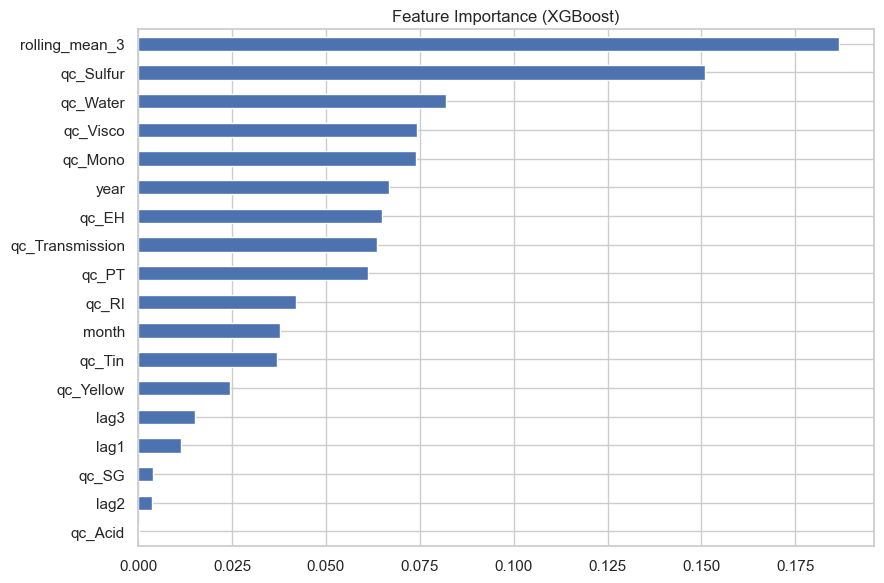

In [21]:
imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(imp)
plt.figure(figsize=(9,6)); imp.sort_values().plot(kind='barh')
plt.title('Feature Importance (XGBoost)'); plt.tight_layout(); plt.show()

## 18. Interpretasi Model (SHAP)

**Tujuan.** Interpretasi lokal & global kontribusi tiap fitur.

**Referensi.** Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions.* NeurIPS.

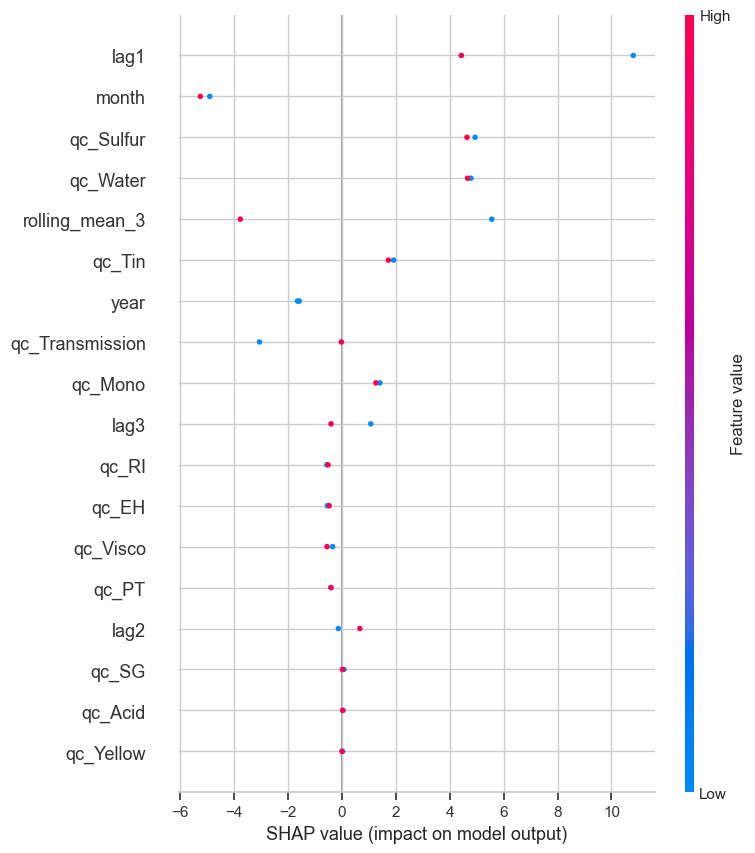

In [22]:
if HAS_SHAP and len(X_train)>=2:
    try:
        explainer = shap.TreeExplainer(best_model)
        Xref = X_test if len(X_test)>0 else X_train
        sv = explainer.shap_values(Xref)
        shap.summary_plot(sv, pd.DataFrame(Xref, columns=feature_cols), show=True)
    except Exception as e:
        print('SHAP gagal:', e)
else:
    print('SHAP tidak tersedia / data terlalu sedikit. Jalankan: pip install shap')

## 19. Visualisasi Hasil & Prediksi Bulan Depan

**Tujuan.** Actual vs Prediction, residual, dan **prediksi jumlah produksi bulan berikutnya**.

**Referensi.** Hyndman & Athanasopoulos (2021), *Forecasting: Principles and Practice.* OTexts.

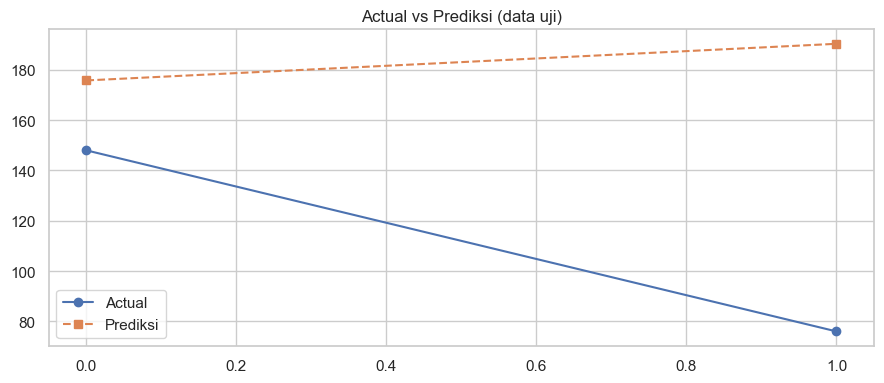

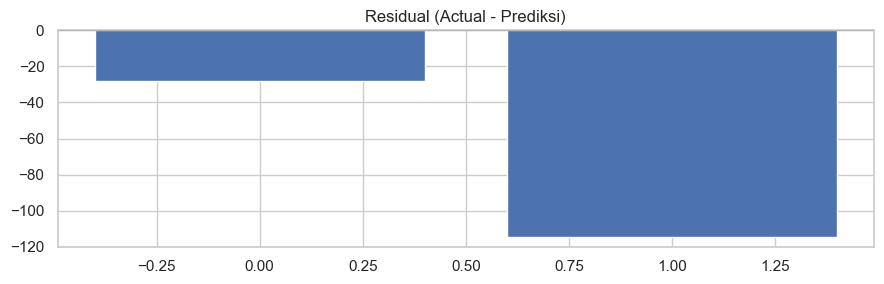

PREDIKSI jumlah produksi untuk 2026-05 = 191 batch
(catatan: bulan terakhir mungkin parsial sehingga lag1 bisa bias)


In [23]:
plt.figure(figsize=(9,4)); idx=range(len(y_test))
plt.plot(idx,y_test,'o-',label='Actual'); plt.plot(idx,y_pred,'s--',label='Prediksi')
plt.title('Actual vs Prediksi (data uji)'); plt.legend(); plt.tight_layout(); plt.show()

resid=y_test-y_pred
plt.figure(figsize=(9,3)); plt.bar(idx,resid); plt.axhline(0,color='k')
plt.title('Residual (Actual - Prediksi)'); plt.tight_layout(); plt.show()

last = monthly['Jumlah_Produksi']; row={}
row['lag1']=last.iloc[-1]; row['lag2']=last.iloc[-2]; row['lag3']=last.iloc[-3]
row['rolling_mean_3']=last.iloc[-3:].mean()
next_period = monthly.index[-1] + 1
row['month']=next_period.month; row['year']=next_period.year
for c in qc: row[f'qc_{c}']=monthly[c].iloc[-1]
x_next = np.array([[row[c] for c in feature_cols]])
pred_next = best_model.predict(x_next)[0]
print(f'PREDIKSI jumlah produksi untuk {next_period} = {pred_next:.0f} batch')
print('(catatan: bulan terakhir mungkin parsial sehingga lag1 bisa bias)')

## 19B. Interval Prediksi 95% & Diagnostik Residual  **[TAMBAHAN]**

**Tujuan.** Menyertakan **ketidakpastian** pada prediksi bulan depan melalui interval +/- 1.96 x sigma(residual), serta memeriksa residual (rata-rata mendekati nol, tidak berpola) sebagai diagnostik kelayakan model.

**Referensi.** Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.), bab interval prediksi. OTexts.

Prediksi 2026-05: 191 batch
Interval 95%: [183 , 199]  (sigma residual = 3.97)


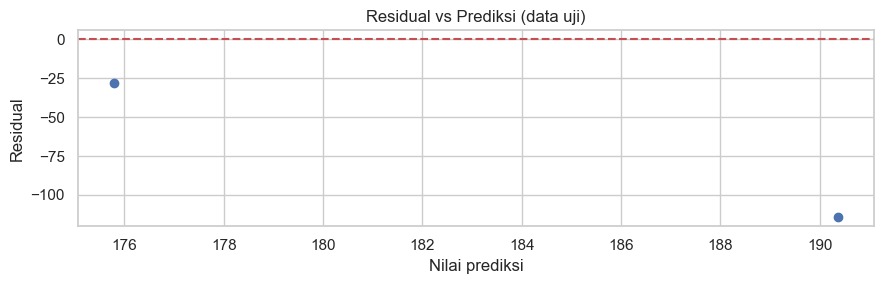

Rata-rata residual uji (idealnya ~0): -71.084


In [24]:
# Menghitung ketidakpastian (sigma) dari residual data uji (out-of-sample), bukan training
# Hal ini mencegah overconfidence (interval terlalu sempit) akibat model overfitting.
resid_val = y_test - best_model.predict(X_test)
sigma = float(np.std(resid_val, ddof=1)) if len(resid_val)>1 else float(np.std(resid_val))
lo, hi = pred_next - 1.96*sigma, pred_next + 1.96*sigma
print(f'Prediksi {next_period}: {pred_next:.0f} batch')
print(f'Interval 95%: [{lo:.0f} , {hi:.0f}]  (sigma residual out-of-sample = {sigma:.2f})')

plt.figure(figsize=(9,3))
plt.scatter(y_pred, y_test - y_pred)
plt.axhline(0,color='r',ls='--')
plt.xlabel('Nilai prediksi'); plt.ylabel('Residual'); plt.title('Residual vs Prediksi (data uji)')
plt.tight_layout(); plt.show()
print('Rata-rata residual uji (idealnya ~0):', round(float(np.mean(y_test - y_pred)),3))


## 20. Menyimpan Model  **[TAMBAHAN]**

**Tujuan.** Menyimpan model agar dapat dipakai kembali tanpa melatih ulang.

In [ ]:
if HAS_JOBLIB:
    joblib.dump(best_model, 'model_xgboost_produksi.pkl')
    print('Model disimpan: model_xgboost_produksi.pkl')
else:
    print('joblib tidak tersedia. Jalankan: pip install joblib')

Model disimpan: model_xgboost_produksi.pkl


: 

## 21. Kesimpulan & Keterbatasan  **[TAMBAHAN: keterbatasan]**

**Kesimpulan.** Model XGBoost dilatih untuk memprediksi jumlah produksi bulan berikutnya, dengan evaluasi
MAE/RMSE/MAPE/R2 dan interpretasi Feature Importance + SHAP.

**Keterbatasan (penting ditulis di skripsi):**
1. **Jumlah data sangat sedikit** (~12 titik bulanan) -> rawan overfitting; hasil bersifat indikatif.
   Idealnya minimal 24-36 bulan agar pola musiman & tren dapat dipelajari.
2. **Tidak ada data proses produksi** (suhu, tekanan, bahan baku) yang merupakan penyebab nyata variasi
   mutu & volume; parameter QC adalah hasil akhir, bukan penyebab.
3. **Target adalah proksi** (jumlah batch/bulan), bukan tonase aktual.
4. Bulan parsial (awal/akhir) dapat membiaskan hasil.

**Saran.**
- Tambahkan pencatatan parameter proses produksi & jumlah/tonase produksi aktual.
- Perpanjang periode data (2-3 tahun) untuk menangkap musiman.
- Bandingkan XGBoost dengan model deret waktu klasik (ARIMA/SARIMA, Holt-Winters) sebagai pembanding.

**Referensi.** Hyndman & Athanasopoulos (2021), *Forecasting: Principles and Practice* (3rd ed.). OTexts;
Hyndman & Koehler (2006), *Another look at measures of forecast accuracy*, IJF.

## Daftar Pustaka

1. Box, G. E. P., & Jenkins, G. M. (1970). *Time Series Analysis: Forecasting and Control.* Holden-Day.
2. Breiman, L. (2001). Random Forests. *Machine Learning, 45*(1), 5-32. https://doi.org/10.1023/A:1010933404324
3. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785-794. https://doi.org/10.1145/2939672.2939785
4. Dickey, D. A., & Fuller, W. A. (1979). Distribution of the Estimators for Autoregressive Time Series with a Unit Root. *Journal of the American Statistical Association, 74*(366), 427-431. https://doi.org/10.2307/2286348
5. Friedman, J. H. (2001). Greedy Function Approximation: A Gradient Boosting Machine. *The Annals of Statistics, 29*(5), 1189-1232. https://doi.org/10.1214/aos/1013203451
6. Harris, C. R., et al. (2020). Array programming with NumPy. *Nature, 585*, 357-362. https://doi.org/10.1038/s41586-020-2649-2
7. Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts. https://otexts.com/fpp3/
8. Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting, 22*(4), 679-688. https://doi.org/10.1016/j.ijforecast.2006.03.001
9. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning.* Springer. https://doi.org/10.1007/978-1-4614-7138-7
10. Kwiatkowski, D., Phillips, P. C. B., Schmidt, P., & Shin, Y. (1992). Testing the null hypothesis of stationarity against the alternative of a unit root. *Journal of Econometrics, 54*(1-3), 159-178. https://doi.org/10.1016/0304-4076(92)90104-Y
11. Lee, J. H., Shin, J., & Realff, M. J. (2018). Machine learning: Overview of the recent progresses and implications for the process systems engineering field. *Computers & Chemical Engineering, 114*, 111-121. https://doi.org/10.1016/j.compchemeng.2017.10.008
12. Lundberg, S. M., & Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. *Advances in Neural Information Processing Systems, 30*, 4765-4774.
13. Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2018). Statistical and Machine Learning forecasting methods: Concerns and ways forward. *PLoS ONE, 13*(3), e0194889. https://doi.org/10.1371/journal.pone.0194889
14. McKinney, W. (2010). Data Structures for Statistical Computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61. https://doi.org/10.25080/Majora-92bf1922-00a
15. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.
16. Probst, P., Boulesteix, A.-L., & Bischl, B. (2019). Tunability: Importance of Hyperparameters of Machine Learning Algorithms. *Journal of Machine Learning Research, 20*(53), 1-32.
17. Tashman, L. J. (2000). Out-of-sample tests of forecasting accuracy: an analysis and review. *International Journal of Forecasting, 16*(4), 437-450. https://doi.org/10.1016/S0169-2070(00)00065-0
18. Tukey, J. W. (1977). *Exploratory Data Analysis.* Addison-Wesley.
